# Vision Transformer (ViT) Fine-tuning Notebook
Bu notebook ön-eğitimli bir ViT modelini kendi veri kümeniz üzerinde fine-tune etmek için hazırlanmıştır.
NOT: Lütfen `dataset_dir` değişkenini veri kümenizin kök yoluna göre güncelleyin (ör. `C:/.../dataset`). Veri kümesi klasör yapısı `train/` ve `test/` alt klasörleri içermeli ve her biri sınıf alt-klasörleri barındırmalıdır.

## Imports
Bu hücre gerekli kütüphanelerin import edildiği yerdir.

In [13]:
# Imports
# Required libraries and utilities (plots, metrics, model helpers)
import os
import time
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

## Configuration
Veri yolu ve eğitim hiperparametrelerini (batch size, epoch sayısı, learning rate vb.) buradan ayarlayın.

In [14]:
# Configuration
# Update dataset path and training hyperparameters below
dataset_dir = r'C:\Users\emirh\Desktop\Projects\datasets\input_sk'
train_dir = os.path.join(dataset_dir, 'train')
val_dir = os.path.join(dataset_dir, 'val')  # validation set folder
test_dir = os.path.join(dataset_dir, 'test')
image_size = 224  # ViT tipik boyutu
batch_size = 32
num_workers = 4
epochs = 50  # önerilen aralık: 5-15
lr = 1e-4
weight_decay = 1e-4
model_name = 'vit_small_patch16_224'  # değiştirmek isterseniz: vit_tiny_*, vit_base_*, vb.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Scheduler / EarlyStopping params
reduce_lr_patience = 4  # ReduceLROnPlateau patience (epochs)
early_stopping_patience = 10  # Early stopping patience (epochs)
print('Using device:', device)

Using device: cuda


## Data Loading and Transforms
Görüntü dönüşümleri hazırlanır ve `ImageFolder` kullanılarak `DataLoader`lar oluşturulur.

In [15]:
# Data Loading and Transforms
# Prepare train/test transforms and create DataLoaders (ImageFolder expected)
train_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])
test_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])
# Datasets: ImageFolder varsayımı
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=test_transforms)  # validation uses test transforms
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)
num_classes = len(train_dataset.classes)
print('Num classes:', num_classes)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

Num classes: 8


## Model
Ön-eğitimli ViT modeli yüklenir ve sınıflandırma başlığı (`head`) `num_classes` olacak şekilde güncellenir.

In [16]:
# Model
# Load a pretrained ViT and adapt the classification head to `num_classes`
model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
model.to(device)
# Parametre sayısı (isteğe bağlı bilgi)
def count_parameters(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)
print('Trainable parameters:', count_parameters(model))

Trainable parameters: 21668744


## Optimizer and Loss
Optimizatör, kayıp fonksiyonu ve (isteğe bağlı) LR scheduler burada tanımlanır.

In [17]:
# Optimizer and Loss
# Set optimizer, loss function and optional LR scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss()
# Use ReduceLROnPlateau to lower LR when val loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=reduce_lr_patience)

## Training
Eğitim döngüsü: modelin fine-tune edildiği, epoch bazlı loss ve accuracy'nin kaydedildiği hücre.

In [18]:
# Training
# Fine-tune the model. This cell logs train/val loss and accuracy per epoch
train_losses = []
val_losses = []
train_accs = []
val_accs = []
start_time = time.time()
# Use the dedicated validation loader
# val_loader is created earlier from the 'val' folder
best_val_loss = float('inf')
no_improve_epochs = 0
best_model_state = None
for epoch in range(1, epochs+1):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    for images, labels in tqdm(train_loader, desc=f'Train Epoch {epoch}/{epochs}', leave=False):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        running_corrects += torch.sum(preds == labels).item()
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects / len(train_dataset)
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    # Validation
    model.eval()
    val_running_loss = 0.0
    val_running_corrects = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Val Epoch {epoch}/{epochs}', leave=False):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_running_corrects += torch.sum(preds == labels).item()
    val_loss = val_running_loss / len(val_loader.dataset)
    val_acc = val_running_corrects / len(val_loader.dataset)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    print(f'Epoch {epoch} - Train Loss: {epoch_loss:.4f} Train Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f}')
    # Step the ReduceLROnPlateau scheduler with the validation loss
    try:
        scheduler.step(val_loss)
    except Exception:
        pass
    # Early stopping: save best model when val_loss improves
    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        no_improve_epochs = 0
        best_model_state = { 'model_state_dict': model.state_dict(), 'classes': train_dataset.classes }
        print(f'	Validation loss improved; saving best model (val_loss={best_val_loss:.4f})')
    else:
        no_improve_epochs += 1
        print(f'	No improvement for {no_improve_epochs}/{early_stopping_patience} epochs')
    if no_improve_epochs >= early_stopping_patience:
        print('Early stopping triggered')
        break
# After training, if we have a best model saved in memory, persist it
total_time = time.time() - start_time
print(f'Training finished, elapsed time: {total_time:.1f} seconds')
try:
    results_dir = os.path.join(os.getcwd(), 'results', model_name)
    os.makedirs(results_dir, exist_ok=True)
    if best_model_state is not None:
        out_path = os.path.join(results_dir, f'{model_name}_finetuned_best.pth')
        torch.save(best_model_state, out_path)
        print('Saved best model to', out_path)
except Exception as e:
    print('Could not save best model:', e)

Epoch 1 - Train Loss: 0.8530 Train Acc: 0.6971 | Val Loss: 0.7094 Val Acc: 0.7330
	Validation loss improved; saving best model (val_loss=0.7094)


Epoch 2 - Train Loss: 0.6018 Train Acc: 0.7818 | Val Loss: 0.5915 Val Acc: 0.7816
	Validation loss improved; saving best model (val_loss=0.5915)


Epoch 3 - Train Loss: 0.4274 Train Acc: 0.8446 | Val Loss: 0.6489 Val Acc: 0.7697
	No improvement for 1/10 epochs


Epoch 4 - Train Loss: 0.3064 Train Acc: 0.8900 | Val Loss: 0.6057 Val Acc: 0.7954
	No improvement for 2/10 epochs


Epoch 5 - Train Loss: 0.2022 Train Acc: 0.9261 | Val Loss: 0.6529 Val Acc: 0.7934
	No improvement for 3/10 epochs


...

Epoch 8 - Train Loss: 0.0353 Train Acc: 0.9877 | Val Loss: 0.6664 Val Acc: 0.8250
	No improvement for 6/10 epochs


Epoch 9 - Train Loss: 0.0156 Train Acc: 0.9952 | Val Loss: 0.6632 Val Acc: 0.8420
	No improvement for 7/10 epochs


Epoch 10 - Train Loss: 0.0220 Train Acc: 0.9930 | Val Loss: 0.7464 Val Acc: 0.8294
	No improvement for 8/10 epochs


Epoch 11 - Train Loss: 0.0235 Train Acc: 0.9922 | Val Loss: 0.7949 Val Acc: 0.8373
	No improvement for 9/10 epochs


Epoch 12 - Train Loss: 0.0219 Train Acc: 0.9920 | Val Loss: 0.7963 Val Acc: 0.8231
	No improvement for 10/10 epochs
Early stopping triggered
Training finished, elapsed time: 2026.7 seconds
Saved best model to c:\Users\emirh\Desktop\Projects\DermaViT\results\vit_small_patch16_224\vit_small_patch16_224_finetuned_best.pth


## Save Model
Model ağırlıklarını ve sınıf listesini çalışma dizinine kaydeder.

In [19]:
# Save Model
# Persist fine-tuned model weights and class names to results/<model_name> directory
results_dir = os.path.join(os.getcwd(), 'results', model_name)
os.makedirs(results_dir, exist_ok=True)
out_path = os.path.join(results_dir, f'{model_name}_finetuned.pth')
torch.save({'model_state_dict': model.state_dict(), 'classes': train_dataset.classes}, out_path)
print('Saved model to', out_path)

Saved model to c:\Users\emirh\Desktop\Projects\DermaViT\results\vit_small_patch16_224\vit_small_patch16_224_finetuned.pth


## Inference / Predictions
Test verisi üzerinde modelin tahminlerini toplayın; sonuçlar bir sonraki hücrede görselleştirilecek.

In [20]:
# Inference / Predictions
# Run the model on the test set and collect predictions for later analysis
import numpy as np
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Predicting'):
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())
# Convert to numpy arrays for downstream cells
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
print('Collected', len(all_preds), 'predictions')

Predicting: 100%|██████████| 159/159 [00:45<00:00,  3.50it/s]


Collected 5067 predictions


## Results: Metrics and Visualizations
Bu hücre hesaplanan metrikleri yazdırır ve eğitim/validasyon eğrilerini ile karışıklık matrisini çizer.

Accuracy: 0.8107
Precision (macro): 0.7526
Recall (macro): 0.6523
F1-score (macro): 0.6849


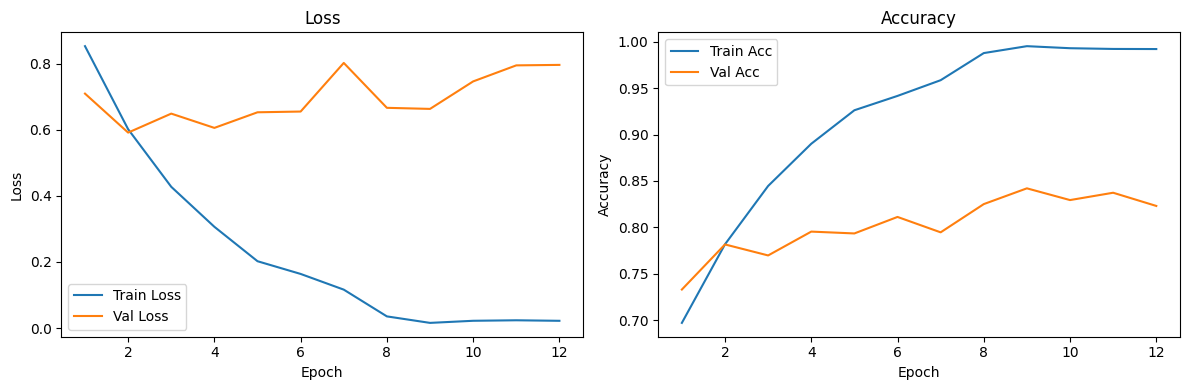

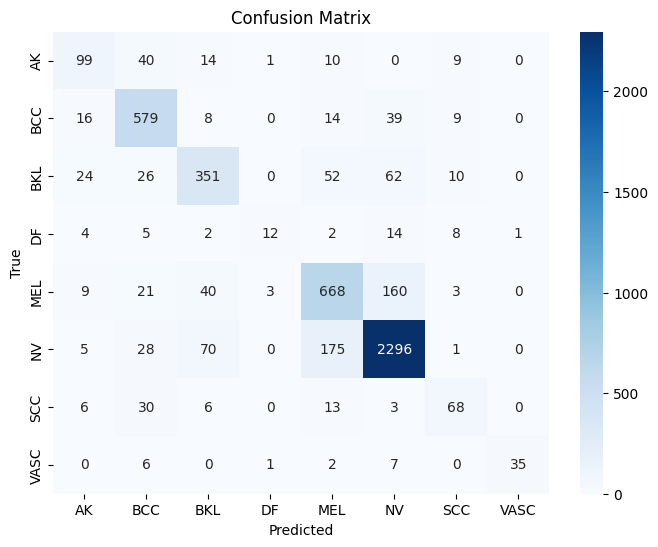

In [21]:
# Results: Metrics and Visualizations
# Compute macro metrics and plot loss/accuracy curves and confusion matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
print(f'Accuracy: {acc:.4f}')
print(f'Precision (macro): {prec:.4f}')
print(f'Recall (macro): {rec:.4f}')
print(f'F1-score (macro): {f1:.4f}')
# Plot train/val loss and accuracy if recorded
try:
    epochs_range = range(1, len(train_losses)+1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs_range, train_losses, label='Train Loss')
    plt.plot(epochs_range, val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss')
    plt.subplot(1,2,2)
    plt.plot(epochs_range, train_accs, label='Train Acc')
    plt.plot(epochs_range, val_accs, label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy')
    plt.tight_layout()
    # Ensure results directory exists and save the figure
    results_dir = os.path.join(os.getcwd(), 'results', model_name)
    os.makedirs(results_dir, exist_ok=True)
    plt.savefig(os.path.join(results_dir, 'loss_acc.png'))
    plt.show()
except NameError:
    print('Train/val history not found; graphs skipped.')
# Confusion matrix
try:
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    # Save confusion matrix to results folder
    plt.savefig(os.path.join(results_dir, 'confusion_matrix.png'))
    plt.show()
except Exception as e:
    print('Could not plot confusion matrix:', e)